#  Embeddings
###  **DSBA 6165: AI & Deep Learning**
### Minwoo "Jake" Lee

## Goal

The goal of this lab activity is modern RNN architectures. We practice to build LSTM variants and then apply to text data.

Let us first import the libraries we are going to use. TensorFlow for DL models, matplotlib and seaborn for plotting data/results, numpy and pandas for data handling. This time, to shorten the code, we directly import more keras models and tools.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.datasets import imdb # IMDB dataset is included in Keras

from keras.models import Sequential  # Model type to be used
from keras.layers import Dense, Dropout, Activation # Types of layers to be used in our model
from keras.layers import Embedding, LSTM
from tensorflow.keras.utils import to_categorical          # Converts a class vector (integers) to binary class matrix.
from tensorflow.keras import regularizers

print("TF version:", tf.__version__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import random                        # for generating random numbers
import string

%matplotlib inline

TF version: 2.20.0


In [3]:
def plot_learning(history):
    tgts = ['loss', 'accuracy']
    vtgts = ['val_loss', 'val_accuracy']

    plt.figure(figsize=(10,3))
    for i, (tgt, val_tgt) in enumerate(zip(tgts, vtgts)):
      plt.subplot(1,2, i+1)
      plt.plot(history.history[tgt], label=tgt)
      plt.plot(history.history[val_tgt], label=val_tgt)
      plt.xlabel('Epoch')
      #plt.ylabel(ylab)
      plt.legend()
      plt.title(f"Training and validation {tgt}")

## IMDB movie review sentiment classification datasetfrom Keras

Let us reuse IMDB dataset that we used last week. But this time, let us use the one in the Keras datasets.

## TODO 1: Load IMDB dataset
**Implement:**
- Set `max_features = 20000`.
- Load the dataset with `keras.datasets.imdb.load_data(num_words=max_features)`.
- Print the number of train and test sequences.

**Checkpoint:** You should get about 25,000 train and 25,000 test samples.

In [4]:
# TODO
max_features = 20000
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

In [12]:
# TODO
x_train[0][:10]

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]

In [21]:
# TODO
for i in range(len(x_train)):
    if i < 5:
        print(f"len {i}: {len(x_train[i])}") 
    else:
        break

len 0: 218
len 1: 189
len 2: 141
len 3: 550
len 4: 147


## TODO 2: Pad sequences
- Import `pad_sequences`.
- Set `maxlen = 80`.
- Pad both `x_train` and `x_test` to length 80.
- Print resulting shapes.

**Checkpoint:** Shapes should be `(25000, 80)` for both train and test.

In [24]:
from keras.utils import pad_sequences
# TODO
maxlen = 80
x_train = pad_sequences(x_train, maxlen)
x_test = pad_sequences(x_test, maxlen)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (25000, 80)
x_test shape: (25000, 80)


In [29]:
# TODO
x_train[0]

array([   15,   256,     4,     2,     7,  3766,     5,   723,    36,
          71,    43,   530,   476,    26,   400,   317,    46,     7,
           4, 12118,  1029,    13,   104,    88,     4,   381,    15,
         297,    98,    32,  2071,    56,    26,   141,     6,   194,
        7486,    18,     4,   226,    22,    21,   134,   476,    26,
         480,     5,   144,    30,  5535,    18,    51,    36,    28,
         224,    92,    25,   104,     4,   226,    65,    16,    38,
        1334,    88,    12,    16,   283,     5,    16,  4472,   113,
         103,    32,    15,    16,  5345,    19,   178,    32])

# Understanding word embeddings

Crucially, when you encode something via one-hot encoding, you’re making a feature- engineering decision. You’re injecting into your model a fundamental assumption about the structure of your feature space. That assumption is that the different tokens you’re encoding are all independent from each other: indeed, one-hot vectors are all orthogonal to one another. And in the case of words, that assumption is clearly wrong. Words form a structured space: they share information with each other. The words “movie” and “film” are interchangeable in most sentences, so the vector that represents “movie” should not be orthogonal to the vector that represents “film”—they should be
the same vector, or close enough.

To get a bit more abstract, the geometric relationship between two word vectors
should reflect the semantic relationship between these words. For instance, in a reasonable word vector space, you would expect synonyms to be embedded into similar word vectors, and in general, you would expect the geometric distance (such as the cosine distance or L2 distance) between any two word vectors to relate to the “semantic distance” between the associated words. Words that mean different things should lie far away from each other, whereas related words should be closer.

Word embeddings are vector representations of words that achieve exactly this: they map human language into a structured geometric space. Whereas the vectors obtained through one-hot encoding are binary, sparse (mostly made of zeros), and very high-dimensional (the same dimensionality as the numb words in the vocabulary), word embeddings are low-dimensional floating-point vectors
(that is, dense vectors, as opposed to sparse vectors); see figure 11.2. It’s common to see word embeddings that are 256-dimensional, 512-dimensional, or 1,024-dimensional when dealing with very large vocabularies. On the other hand, one-hot encoding words generally leads to vectors that are 20,000-dimensional or greater (capturing a vocabulary of 20,000 tokens, in this case). So, word embeddings pack more information into far fewer dimensions.

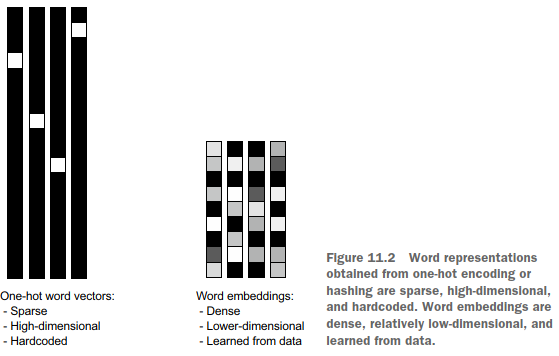

Besides being dense representations, word embeddings are also structured representations, and their structure is learned from data. Similar words get embedded in close locations, and further, specific directions in the embedding space are meaningful. To make this clearer, let’s look at a concrete example.
Four words are embedded on a 2D plane: cat, dog, wolf, and tiger. With the vector representations we chose here, some semantic relationships between these words can be encoded as geometric transformations. For instance, the same vector allows us to go from cat to tiger and from dog to wolf: this vector could be interpreted as the “from pet to wild animal” vector. Similarly, another vector lets us go from dog to cat and from wolf to tiger, which could be interpreted as a “from canine to feline” vector.

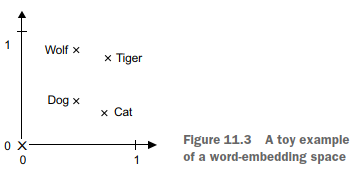

Is there some ideal word-embedding space that would perfectly map human language
and could be used for any natural language processing task? Possibly, but we have yet to compute anything of the sort. Also, there is no such a thing as human language—there are many different languages, and they aren’t isomorphic to one another, because a language is the reflection of a specific culture and a specific context. But more pragmatically, what makes a good word-embedding space depends heavily on your task: the perfect word-embedding space for an English-language movie-review sentiment-analysis model may look different from the perfect embedding space for an English-language legal-document classification model, because the importance of certain semantic relationships varies from task to task.

It’s thus reasonable to learn a new embedding space with every new task. Fortunately, backpropagation makes this easy, and Keras makes it even easier. It’s about learning the weights of a layer: the Embedding layer.

In [30]:
embedding_layer = layers.Embedding(input_dim=max_features, output_dim=256) # The Embedding layer takes at least two arguments: the number of
                                                                         # possible tokens and the dimensionality of the embeddings (here, 256).

The Embedding layer is best understood as a dictionary that maps integer indices
(which stand for specific words) to dense vectors. It takes integers as input, looks up these integers in an internal dictionary, and returns the associated vectors. It’s effectively a dictionary lookup (see figure 11.4).

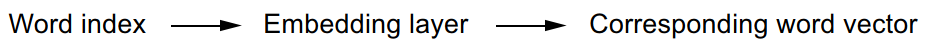

The Embedding layer takes as input a rank-2 tensor of integers, of shape (batch_size, sequence_length), where each entry is a sequence of integers. The layer then returns a 3D floating-point tensor of shape (batch_size, sequence_length, embedding_dimensionality).

When you instantiate an Embedding layer, its weights (its internal dictionary of
token vectors) are initially random, just as with any other layer. During training, these word vectors are gradually adjusted via backpropagation, structuring the space into something the downstream model can exploit. Once fully trained, the embedding space will show a lot of structure—a kind of structure specialized for the specific problem for which you’re training your model. Let’s build a model that includes an Embedding layer and benchmark it on our task.

## TODO 3: Baseline embedding model
**Implement:**
- Build a sentiment model with a trainable embedding layer.
- Use this architecture: `Embedding(max_features, 128)` -> BiLSTM(32, return_sequences=True) -> BiLSTM(32) -> Dropout(0.5) -> Dense(1, sigmoid).
- Compile with `binary_crossentropy`, `adam`, and `accuracy`.
- Train, evaluate on test data, and plot learning curves.

**Checkpoint:** Model runs without shape errors and accuracy improves over epochs.

In [45]:
# inputs = keras.Input(shape=(None,), dtype="int64")
# embed = layers.Embedding(max_features, 128)(inputs)
# x = layers.Bidirectional(layer = layers.LSTM(32, return_sequences = True))(embed)
# x = layers.Bidirectional(layer = layers.LSTM(32))(x)
# x = layers.Dropout(0.5)(x)
# outputs = layers.Dense(1, "sigmoid")(x)

# bidirectional_lstm = keras.Model(inputs, outputs)

bidirectional_lstm = keras.Sequential()
bidirectional_lstm.add(layers.Embedding(max_features, 128))
bidirectional_lstm.add(layers.Bidirectional(layer = layers.LSTM(32, return_sequences = True)))
bidirectional_lstm.add(layers.Bidirectional(layer = layers.LSTM(32)))
bidirectional_lstm.add(layers.Dropout(0.5))
bidirectional_lstm.add(layers.Dense(1, "sigmoid"))

bidirectional_lstm.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 80, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ (None, 80, 64)         │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_16                │ (None, 64)             │        24,832 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,878,341 (30.05 MB)

 Trainable params: 2,626,113 (10.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,252,228 (20.04 MB)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.7996 - loss: 0.4234 - val_accuracy: 0.8489 - val_loss: 0.3458
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.9121 - loss: 0.2249 - val_accuracy: 0.8339 - val_loss: 0.3868
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.9604 - loss: 0.1087 - val_accuracy: 0.8217 - val_loss: 0.5465
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.9819 - loss: 0.0523 - val_accuracy: 0.8191 - val_loss: 0.7578
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.9914 - loss: 0.0280 - val_accuracy: 0.8260 - val_loss: 0.7741
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.9945 - loss: 0.0178 - val_accuracy: 0.8196 - val_loss: 0.9356
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.9964 - loss: 0.0126 - val_accuracy: 0.8108 - val_loss: 0.8595
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.9955 - loss: 0.0140 - 

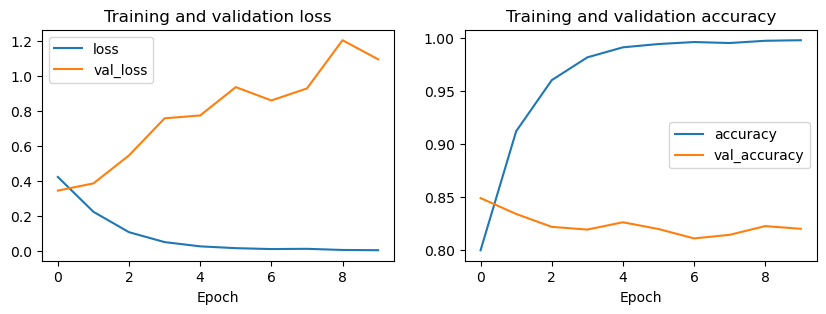

In [49]:
# TODO
bidirectional_lstm.summary()

bidirectional_history = bidirectional_lstm.fit(x_train, y_train, epochs = 10, validation_data=(x_test, y_test))

plot_learning(bidirectional_history)

It trains much faster than the one-hot model (since the LSTM only has to process
256-dimensional vectors instead of 20,000-dimensional), and its test accuracy is comparable (86.2%). However, we’re still some way off from the results of our bidirectional LSTM model last week. Part of the reason why is simply that the model is looking at less data: the bigram model processed full reviews, while our sequence model truncates sequences after 80 words.

### Understanding Padding and Masking

One thing that’s slightly hurting model performance here is that our input sequences are full of zeros. This comes from our use of the output_sequence_length: sentences longer than 80 tokens are truncated to a length of 80 tokens, and sentences shorter than 80 tokens are padded with zeros at the end so that they can be concatenated together with other sequences to form contiguous batches.

We’re using a bidirectional RNN: two RNN layers running in parallel, with one
processing the tokens in their natural order, and the other processing the same
tokens in reverse. The RNN that looks at the tokens in their natural order will spend its last iterations seeing only vectors that encode padding—possibly for several hundreds of iterations if the original sentence was short. The information stored in the internal state of the RNN will gradually fade out as it gets exposed to these meaningless inputs.

We need some way to tell the RNN that it should skip these iterations. There’s an API for that: masking. The Embedding layer is capable of generating a “mask” that corresponds to its input data. This mask is a tensor of ones and zeros (or True/False booleans), of shape (batch_size, sequence_length), where the entry mask[i, t] indicates where time-step t of sample i should be skipped or not (the timestep will be skipped if mask[i, t] is 0 or False, and processed otherwise).

By default, this option isn’t active—you can turn it on by passing mask_zero=True to your Embedding layer. You can retrieve the mask with the compute_mask() method:

In [50]:
embedding_layer = Embedding(input_dim=10, output_dim=256, mask_zero=True)
some_input = [
[4, 3, 2, 1, 0, 0, 0],
[5, 4, 3, 2, 1, 0, 0],
[2, 1, 0, 0, 0, 0, 0]]
mask = embedding_layer.compute_mask(some_input)
mask

<tf.Tensor: shape=(3, 7), dtype=bool, numpy=
array([[ True,  True,  True,  True, False, False, False],
       [ True,  True,  True,  True,  True, False, False],
       [ True,  True, False, False, False, False, False]])>

In practice, you will almost never have to manage masks by hand. Instead, Keras will automatically pass on the mask to every layer that is able to process it (as a piece of metadata attached to the sequence it represents). This mask will be used by RNN layers to skip masked steps. If your model returns an entire sequence, the mask will also be used by the loss function to skip masked steps in the output sequence. Let’s try retraining our model with masking enabled.

## TODO 4: Masked embedding model
- Rebuild the model using an embedding layer with `mask_zero=True`.
- Prefer Functional API (`keras.Input` -> layers -> `keras.Model`) for clearer mask flow.
- Compile and train for **one epoch only**.
- Evaluate and compare with TODO 3.

**Checkpoint:** Training runs with masking enabled and you can comment on differences vs baseline.



<font color="red"> CAUTION: This cell takes long computation. Make sure to run only one epoch. </font>

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_18        │ (None, None, 128) │  2,560,000 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, None)      │          0 │ input_layer_9[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_23    │ (None, None, 64)  │     41,216 │ embedding_18[0][… │
│ (Bidirectional)     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_24    │ (None, 64)        │     24,832 │ bidirectional_23… │
│ (Bidirectional)     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ bidirectional_24… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,626,113 (10.02 MB)

 Trainable params: 2,626,113 (10.02 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 70ms/step - accuracy: 0.8069 - loss: 0.4191 - val_accuracy: 0.8449 - val_loss: 0.3577
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.9085 - loss: 0.2322 - val_accuracy: 0.8440 - val_loss: 0.3580


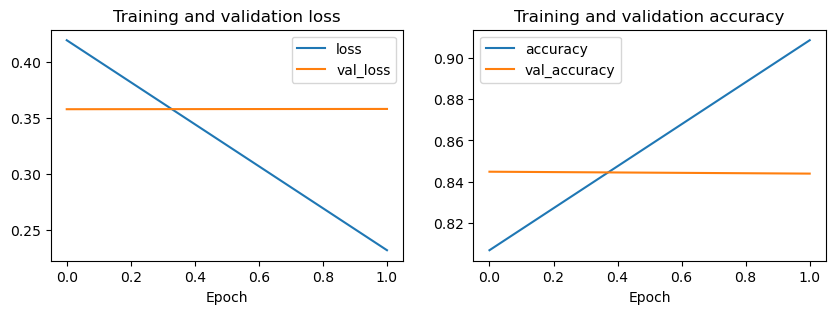

In [54]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
import sys
# from keras.models import Sequential # Using functional API instead
# from keras.layers import Dense, Dropout, Activation # Use tf.keras.layers for consistency
# from keras.layers import Embedding, LSTM # Use tf.keras.layers for consistency

# TODO
# Using an Embedding layer with masking enable
# Use Functional API to explicitly define inputs to avoid potential ambiguity with Sequential model + mask_zero=True

inputs = keras.Input(shape=(None,), dtype="int64")
embed = tf.keras.layers.Embedding(max_features, 128, mask_zero = True)(inputs)
x = tf.keras.layers.Bidirectional(layer = tf.keras.layers.LSTM(32, return_sequences = True))(embed)
x = tf.keras.layers.Bidirectional(layer = tf.keras.layers.LSTM(32))(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, "sigmoid")(x)

bidirectional_lstm = tf.keras.Model(inputs, outputs)

print(bidirectional_lstm.summary())

bidirectional_lstm.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

bidirectional_history = bidirectional_lstm.fit(x_train, y_train, epochs = 2, validation_data=(x_test, y_test))

plot_learning(bidirectional_history)


## **Using pretrained word embeddings**

First, let’s download the GloVe word embeddings precomputed on the 2014
English Wikipedia dataset. It’s an 822 MB zip file containing 100-dimensional embedding vectors for 400,000 words (or non-word tokens).

In [55]:
# Download the dataset
%%bash
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

UsageError: Line magic function `%%bash` not found.


Let’s parse the unzipped file (a .txt file) to build an index that maps words (as strings) to their vector representation.

## TODO 5: Parse GloVe vectors
- Set `path_to_glove_file = 'glove.6B.100d.txt'`.
- Initialize `embeddings_index = {}`.
- Read the file line-by-line, split into `word` and vector coefficients.
- Convert coefficients to float array with `np.fromstring(..., sep=' ')` and store in the dictionary.
- Print the number of vectors loaded.

**Checkpoint:** You should load roughly 400,000 vectors from `glove.6B.100d.txt`.

In [2]:
# Parsing the GloVe word-embeddings file

# TODO
path_to_glove_file = 'glove.6B.100d.txt'
embeddings_index = {}

# TODO
i = 0
with open(path_to_glove_file, "+r") as file:
    for line in file:
        word = line.split(" ")[0]
        vector = " ".join(line.split(" ")[1:])
        embeddings_index[word] = np.fromstring(vector, sep=' ')

print(f"Fount {len(embeddings_index)} word vectors.")

Fount 400000 word vectors.


In [69]:
import itertools as it

dict(it.islice(embeddings_index.items(), 2))

{'the': array([-0.038194, -0.24487 ,  0.72812 , -0.39961 ,  0.083172,  0.043953,
        -0.39141 ,  0.3344  , -0.57545 ,  0.087459,  0.28787 , -0.06731 ,
         0.30906 , -0.26384 , -0.13231 , -0.20757 ,  0.33395 , -0.33848 ,
        -0.31743 , -0.48336 ,  0.1464  , -0.37304 ,  0.34577 ,  0.052041,
         0.44946 , -0.46971 ,  0.02628 , -0.54155 , -0.15518 , -0.14107 ,
        -0.039722,  0.28277 ,  0.14393 ,  0.23464 , -0.31021 ,  0.086173,
         0.20397 ,  0.52624 ,  0.17164 , -0.082378, -0.71787 , -0.41531 ,
         0.20335 , -0.12763 ,  0.41367 ,  0.55187 ,  0.57908 , -0.33477 ,
        -0.36559 , -0.54857 , -0.062892,  0.26584 ,  0.30205 ,  0.99775 ,
        -0.80481 , -3.0243  ,  0.01254 , -0.36942 ,  2.2167  ,  0.72201 ,
        -0.24978 ,  0.92136 ,  0.034514,  0.46745 ,  1.1079  , -0.19358 ,
        -0.074575,  0.23353 , -0.052062, -0.22044 ,  0.057162, -0.15806 ,
        -0.30798 , -0.41625 ,  0.37972 ,  0.15006 , -0.53212 , -0.2055  ,
        -1.2526  ,  0.071624,  

Next, let’s build an embedding matrix that you can load into an Embedding layer. It must be a matrix of shape (max_words, embedding_dim), where each entry i contains the embedding_dim-dimensional vector for the word of index i in the reference word index (built during tokenization).

In [70]:
len(imdb.get_word_index())

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


88584

## TODO 6: Build embedding matrix
- Set `embedding_dim = 100`.
- Create `embedding_matrix = np.zeros((max_features, embedding_dim))`.
- Iterate over `imdb.get_word_index()`.
- For each `(word, i)`, skip indices `>= max_features`.
- If the word exists in `embeddings_index`, copy vector into row `i`; otherwise keep zeros.
- Track `hits` and `misses`, then print both.

**Checkpoint:** Matrix shape must be `(20000, 100)` and misses should be non-zero.

In [53]:
# TODO
# Preparing the GloVe word-embeddings matrix
embedding_dim = 100
embedding_matrix = np.zeros(shape = (max_features, embedding_dim))
hits = misses = 0
word_index = imdb.get_word_index()

for word, index in word_index.items():
    if index < max_features and word in list(embeddings_index.keys()):
        embedding_matrix[index] = embeddings_index[word]
        hits += 1

    elif index < max_features and word not in list(embeddings_index.keys()):
        misses += 1


# for word, i in word_index.items():
#     if i >= max_features: continue
#     embedding_vector = embeddings_index.get(word)
#     if embedding_vector is not None:
#         hits += 1
#        embedding_matrix[i] = embedding_vector
#     else:
#         misses += 1




print(f"Converted {hits} words ({misses} misses)")

Converted 19131 words (868 misses)


Finally, we use a Constant initializer to load the pretrained embeddings in an Embedding layer. So as not to disrupt the pretrained representations during training, we freeze the layer via trainable=False:

## TODO 7: Create pretrained embedding layer
- Build an `Embedding` layer initialized from `embedding_matrix`.
- Freeze it with `trainable=False`.
- Keep dimensions consistent with GloVe (`embedding_dim = 100`).
- set `mask_zero=True`

In [88]:
# TODO

inputs = keras.Input(shape=(None,), dtype="int64")
embed = tf.keras.layers.Embedding(input_dim=max_features, output_dim=100, 
                weights=[embedding_matrix], mask_zero = True)(inputs)
x = tf.keras.layers.Bidirectional(layer = tf.keras.layers.LSTM(32, return_sequences = True))(embed)
x = tf.keras.layers.Bidirectional(layer = tf.keras.layers.LSTM(32))(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, "sigmoid")(x)

pretrained_lstm = tf.keras.Model(inputs, outputs)

We’re now ready to train a new model—identical to our previous model, but leveraging the 100-dimensional pretrained GloVe embeddings instead of 128-dimensional learned embeddings.

## TODO 8: Train model with pretrained embeddings
- Build the same sentiment architecture as TODO 3, but use the pretrained `embedding_layer` from TODO 7.
- Compile, train, evaluate, and plot learning curves.
- Keep the rest of the architecture comparable so results are fair.

**Write short comparison notes:**
- validation/test accuracy,

    **The validation accuracy remained fairly similar for all versions. (0.82 with masking, 0.84 without masking, and 0.84 using a pretrained embedder).**
- convergence behavior,

    **The convergence behavior is the same with the model beginning with a high accuracy and a small loss and not changing too much. Perhaps with more epochs I would see an loss decrease of a 10^-2 order of magnitude. But for all models, the loss was already small enough that I would not expect to see a large decrease.**
- whether pretrained embeddings helped on this dataset.

    **Overall, simce the model's loss and metrics did not change much overall, I do not think pretraining helped much.**

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_20        │ (None, None, 100) │  2,000,000 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, None)      │          0 │ input_layer_11[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_27    │ (None, None, 64)  │     34,048 │ embedding_20[0][… │
│ (Bidirectional)     │                   │            │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_28    │ (None, 64)        │     24,832 │ bidirectional_27… │
│ (Bidirectional)     │                   │            │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ bidirectional_28… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         65 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,058,945 (7.85 MB)

 Trainable params: 2,058,945 (7.85 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 127ms/step - accuracy: 0.7428 - loss: 0.5049 - val_accuracy: 0.8297 - val_loss: 0.3819
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.8761 - loss: 0.3009 - val_accuracy: 0.8365 - val_loss: 0.3914


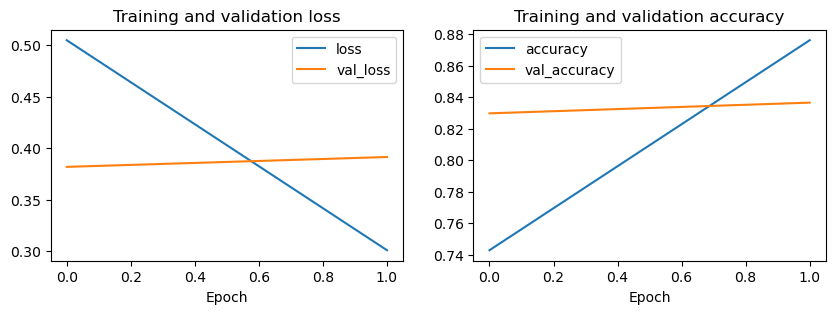

In [90]:
import sys
# TODO
# Model that uses a pretrained Embedding layer

print(pretrained_lstm.summary())

pretrained_lstm.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

pretrained_lstm = pretrained_lstm.fit(x_train, y_train, epochs = 2, validation_data=(x_test, y_test))

plot_learning(pretrained_lstm)

You’ll find that on this particular task, pretrained embeddings aren’t very helpful, because the dataset contains enough samples that it is possible to learn a specialized enough embedding space from scratch. However, leveraging pretrained embeddings can be very helpful when you’re working with a smaller dataset.

### **Synonyms and Analogy**

Learning to discover the embedding space that maintains word-to-word relationship, let us see how synonyms and analgies are found.

TF tutorial has the [Embedding Projector](http://projector.tensorflow.org/?_gl=1*iy51xk*_ga*ODUxNDY1MTU5LjE2NzI3NjkzMjA.*_ga_W0YLR4190T*MTY4MDMzMzYwOC40OC4xLjE2ODAzMzM2NTAuMC4wLjA.) that you can play with.

![](https://www.tensorflow.org/static/text/guide/images/embedding.jpg)

### Helper function explanation (for synonyms)

These helper functions convert between words and embedding indices so we can query nearest neighbors:

- `get_index_by(word)`
  - Input: a token string (for example, `amazon`)
  - Output: its integer index from `word_index`
  - Purpose: fetches the query token's embedding row

- `get_word_by(index)`
  - Input: an integer index
  - Output: the token string with that index
  - Purpose: converts neighbor indices back to readable words



In [ ]:
word_index = imdb.get_word_index()

def get_word_by(index):
  return list(filter(lambda x: word_index[x] == index, word_index))[0]

def get_index_by(word):
  return word_index[word]

In [11]:
get_index_by('beautiful'), get_word_by(304)

(304, 'beautiful')


### Finding Synonyms


Similarity workflow in this notebook:
1. `knn(W, x, k)` computes cosine similarity between query vector `x` and every row in embedding matrix `W`, then returns top-k indices and scores.
2. `get_similar_tokens(query_token, k, embed)` gets the query vector, calls `knn`, removes the query token itself, and prints the nearest words with cosine similarity.

In [15]:
def topk(cos, k):
  idx = np.argpartition(cos, -k)[-k:]  # Indices not sorted
  return idx[np.argsort(cos[idx])][::-1]  # Indices sorted by value from largest to smallest

def knn(W, x, k):
    # The added 1e-9 is for numerical stability
    cos = W @ x.reshape((-1,)) / (
        (np.sqrt(np.sum(W * W, axis=1) + 1e-9) * np.sqrt(np.sum(x * x))))
    i_topk = topk(cos, k) #.asnumpy().astype('int32')
    return i_topk, [cos[i] for i in i_topk]

Then, we search for synonyms by pre-training the word vector instance `embed`.

In [16]:
def get_similar_tokens(query_token, k, embed):
    topk, cos = knn(embed,
                    embed[get_index_by(query_token)], k+1)
    for i, c in zip(topk[1:], cos[1:]):  # Remove input words
        print(f"cosine sim={c}: {get_word_by(i)}")

## TODO 9: Explore synonyms
- Run `get_similar_tokens` for the provided words.
- Inspect whether nearest neighbors are semantically meaningful.
- Briefly note one good and one surprising result.

**Required Words:** `amazon`, `baby`, `beautiful`

**Implement:**

* Run `get_similar_tokens(word, 3, embedding_matrix)` for each word.
* Inspect whether returned neighbors are semantically meaningful

**Checkpoint:** For each query, priont three nearest neighbors (excluding the query word itself).

**A good results was the semantically similar words for beautiful. The cosine similarity was very high for all three words: 0.89 for lovely, 0.87 for gorgeous, and 0.80 for wonderful. I was a bit surprised that ebay and amazon have such low semantic similarities (0.61) since I consider them to be very similar.**

In [ ]:
# TODO

get_similar_tokens(query_token = "amazon", k=3, embed = embedding_matrix)


cosine sim=0.6066174278583404: ebay
cosine sim=0.5490650682601816: yahoo
cosine sim=0.5455809614561234: google


In [23]:
# TODO
get_similar_tokens(query_token = "baby", k=3, embed = embedding_matrix)


cosine sim=0.7870863638933566: babies
cosine sim=0.7522427729604187: newborn
cosine sim=0.750672980994626: boy


In [24]:
# TODO
get_similar_tokens(query_token = "beautiful", k=3, embed = embedding_matrix)

cosine sim=0.8909063090987163: lovely
cosine sim=0.8721614416670717: gorgeous
cosine sim=0.8080509571650976: wonderful


### Finding Analogies

## TODO 10: Analogies
- Complete/review `get_analogy` logic and run the provided analogy tests.
- Check whether outputs are linguistically reasonable.
- Note one analogy that works well and one that does not.
- Use vector arithmetic `x = vec(b) - vec(a) + vec(c)`.
- Find the nearest token to `x` using `knn` and return that word.

**Goal:** Evaluate whether embedding-space arithmetic captures analogical relationships.


In [41]:
def get_analogy(token_a, token_b, token_c, embed):
    i_tokens = [get_index_by(w) for w in [token_a, token_b, token_c]]
    vecs = embed[i_tokens]
    # TODO
    x = vecs[1] - vecs[0] + vecs[2]
    topk, cos = knn(embed, x, 1)
    for i, c in zip(topk[0:], cos[0:]):  # Remove input words
        print(f"{get_word_by(i)}")
    
    

## TODO 11: Run and interpret analogy test cases
**Required test triples (must include all four):**
- (`man`, `woman`, `boy`)
- (`bad`, `worst`, `nice`)
- (`do`, `did`, `go`)
- (`japan`, `tokyo`, `uk`)

**Implement:**
- Run `get_analogy(a, b, c, embedding_matrix)` for each required triple.
- Report predicted token for each case.
- Judge whether each prediction is semantically reasonable.

**Write-up:** Include at least one analogy that works well and one that fails/looks weak, with a short explanation.

In [44]:
# TODO

get_analogy("man", "woman", "boy", embedding_matrix)

girl


In [ ]:
# TODO

get_analogy("bad", "worst", "nice", embedding_matrix)

'nice'

In [46]:
# TODO
get_analogy("do", "did", "go", embedding_matrix)


went


In [48]:
# TODO
get_analogy("japan", "tokyo", "uk", embedding_matrix)

london
